In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (15509, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [5]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [6]:
df = df.dropna(subset=['Rating'])

df['Year'] = df['Year'].str.extract('(\d+)')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df['Duration'] = df['Duration'].str.extract('(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

df['Votes'] = df['Votes'].astype(str)
df['Votes'] = df['Votes'].str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [7]:
df.describe()

,Year,Duration,Rating,Votes
count,7919.000000,5851.000000,7919.000000,7919.000000
mean,1993.321758,132.294480,5.841621,1938.520394
std,20.463770,26.555826,1.381777,11602.415952
min,1917.000000,21.000000,1.100000,5.000000
25%,1979.500000,117.000000,4.900000,16.000000
50%,1997.000000,134.000000,6.000000,55.000000
75%,2011.000000,150.000000,6.800000,404.000000
max,2021.000000,321.000000,10.000000,591417.000000


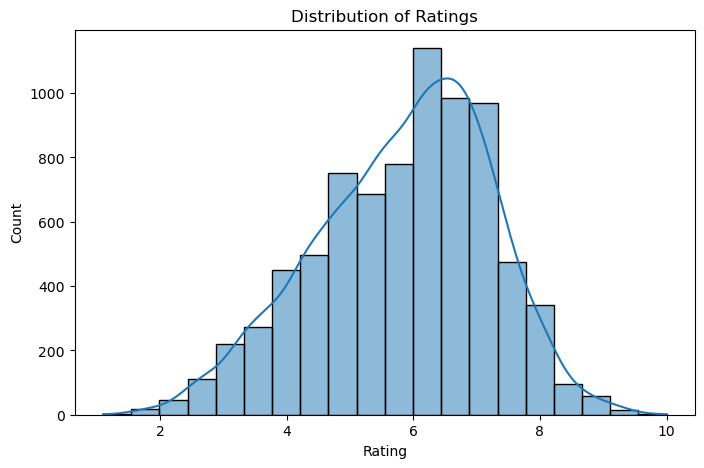

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rating'],
             bins=20,
             kde=True)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

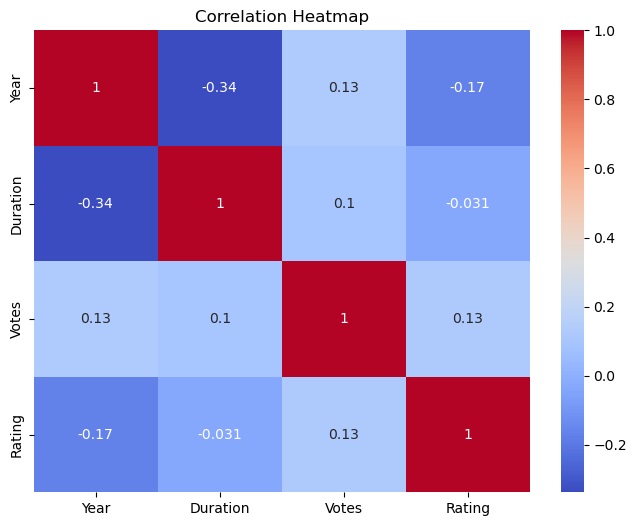

In [9]:
numeric_cols = ['Year',
                'Duration',
                'Votes',
                'Rating']

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

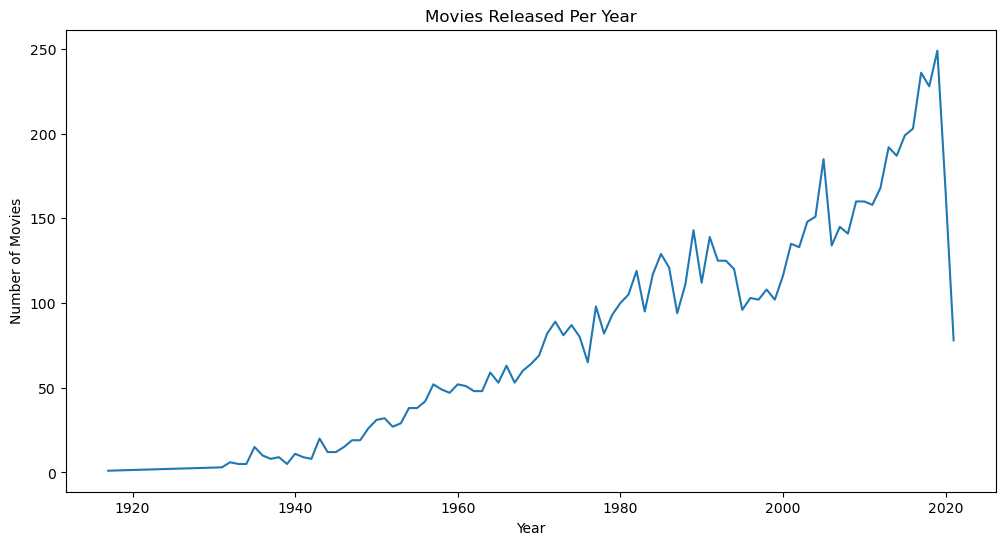

In [10]:
plt.figure(figsize=(12,6))

df['Year'].value_counts().sort_index().plot()

plt.title("Movies Released Per Year")

plt.xlabel("Year")

plt.ylabel("Number of Movies")

plt.show()

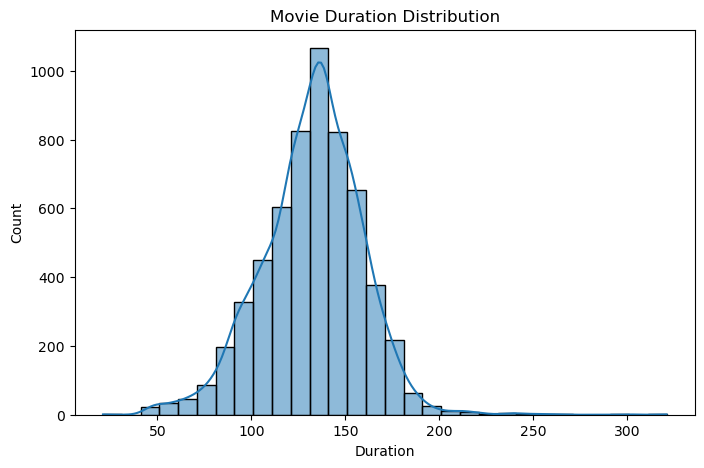

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['Duration'],
             bins=30,
             kde=True)

plt.title("Movie Duration Distribution")

plt.xlabel("Duration")

plt.show()

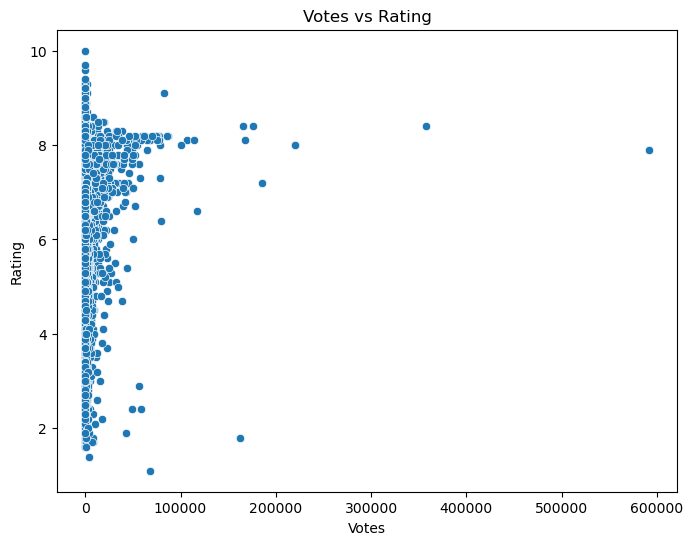

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Votes',
    y='Rating',
    data=df
)

plt.title("Votes vs Rating")

plt.show()

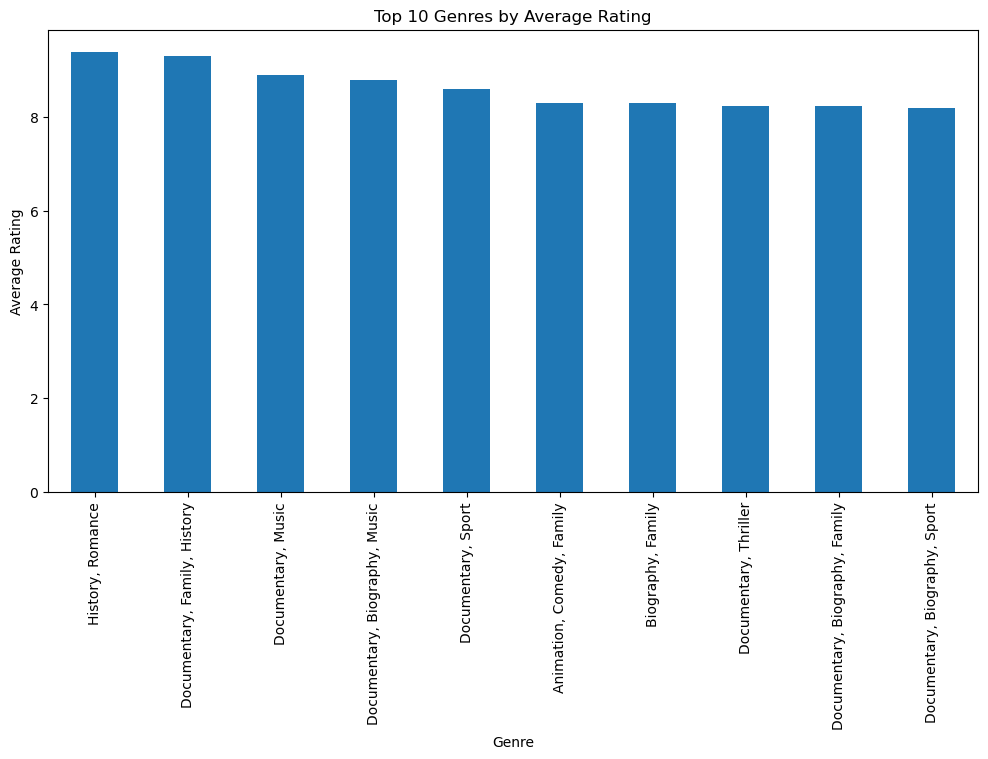

In [13]:
genre_rating = (
    df.groupby('Genre')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

genre_rating.plot(kind='bar')

plt.title("Top 10 Genres by Average Rating")

plt.ylabel("Average Rating")

plt.show()

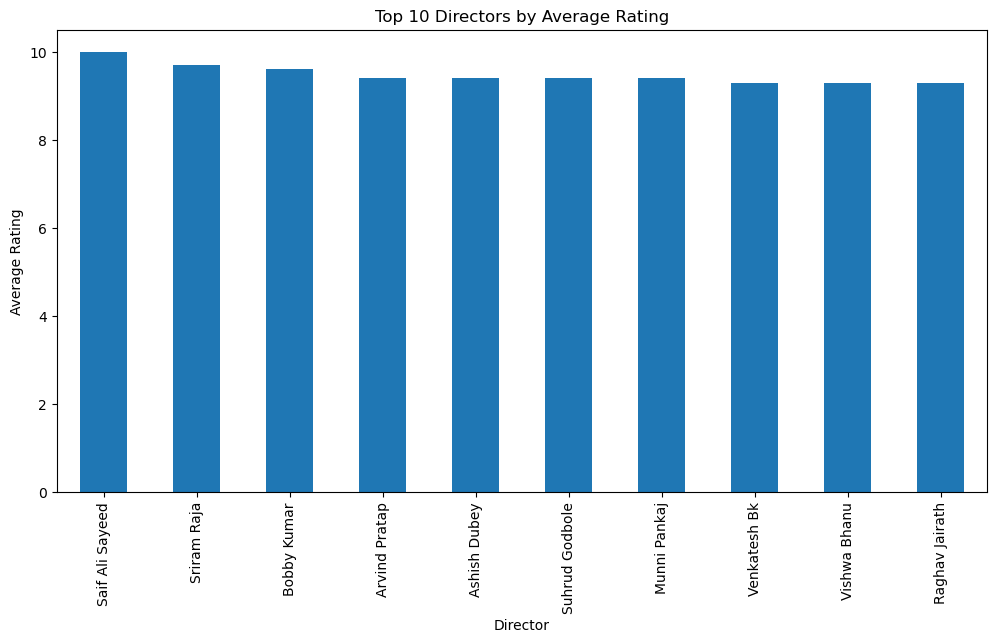

In [14]:
director_rating = (
    df.groupby('Director')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

director_rating.plot(kind='bar')

plt.title("Top 10 Directors by Average Rating")

plt.ylabel("Average Rating")

plt.show()

In [15]:
features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3',
    'Year',
    'Duration',
    'Votes'
]

X = df[features]

y = df['Rating']

In [16]:
categorical_features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

numerical_features = [
    'Year',
    'Duration',
    'Votes'
]

In [17]:
categorical_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='most_frequent')),

        ('encoder',
         OneHotEncoder(handle_unknown='ignore'))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='median'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            categorical_transformer,
            categorical_features
        ),
        (
            'num',
            numerical_transformer,
            numerical_features
        )
    ]
)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6335, 8)
(1584, 8)


In [19]:
model = Pipeline(
    steps=[
        ('preprocessor',
         preprocessor),

        ('regressor',
         RandomForestRegressor(
             n_estimators=200,
             random_state=42
         ))
    ]
)

In [23]:
model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [34]:
from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(model.named_steps['regressor'])
    print("Model is fitted and ready for prediction.")
except:
    print("Model is NOT fitted.")
print("R2 Score :", r2)

Model is fitted and ready for prediction.
R2 Score : 0.375919109203368


In [25]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[3.638  5.2505 6.0035 6.634  5.5955 6.4545 5.155  6.826  5.706  6.349 ]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 0.799315025252525
Mean Squared Error  : 1.1602569554924238
Root Mean Squared Error : 1.0771522434142835
R² Score : 0.375919109203368


In [27]:
comparison = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

comparison.head(20)

,Actual Rating,Predicted Rating
0,3.3,3.6380
1,5.3,5.2505
2,5.7,6.0035
3,7.2,6.6340
4,3.5,5.5955
5,7.2,6.4545
6,3.8,5.1550
7,6.9,6.8260
8,5.2,5.7060
9,7.4,6.3490


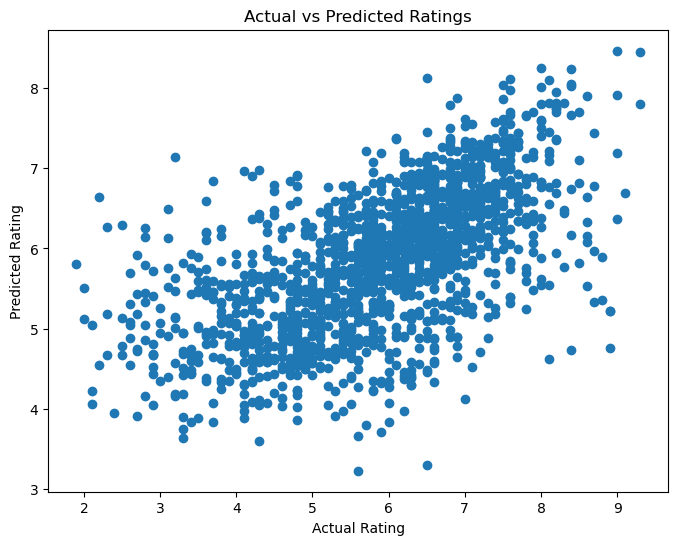

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.show()

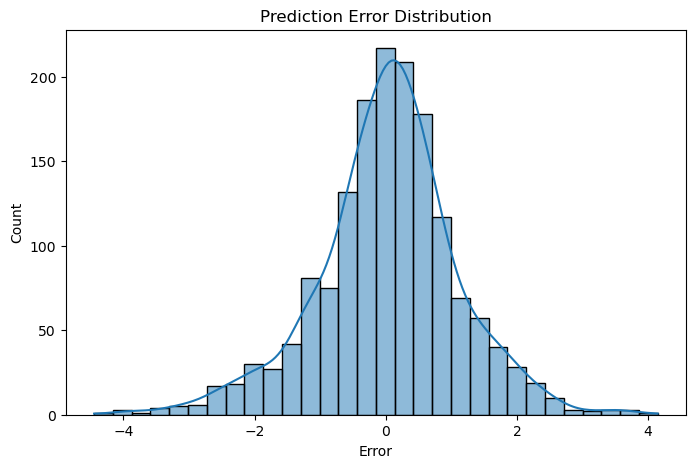

In [29]:
import seaborn as sns

errors = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(errors,
             bins=30,
             kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")

plt.show()

In [30]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importances = model.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
10353,num__Votes,0.200039
10351,num__Year,0.176200
10352,num__Duration,0.073626
236,cat__Genre_Drama,0.022012
213,cat__Genre_Documentary,0.017398
9281,cat__Actor 3_Pran,0.011518
324,cat__Genre_Horror,0.005485
6984,cat__Actor 2_Rekha,0.004516
0,cat__Genre_Action,0.003564
249,"cat__Genre_Drama, Family",0.002898


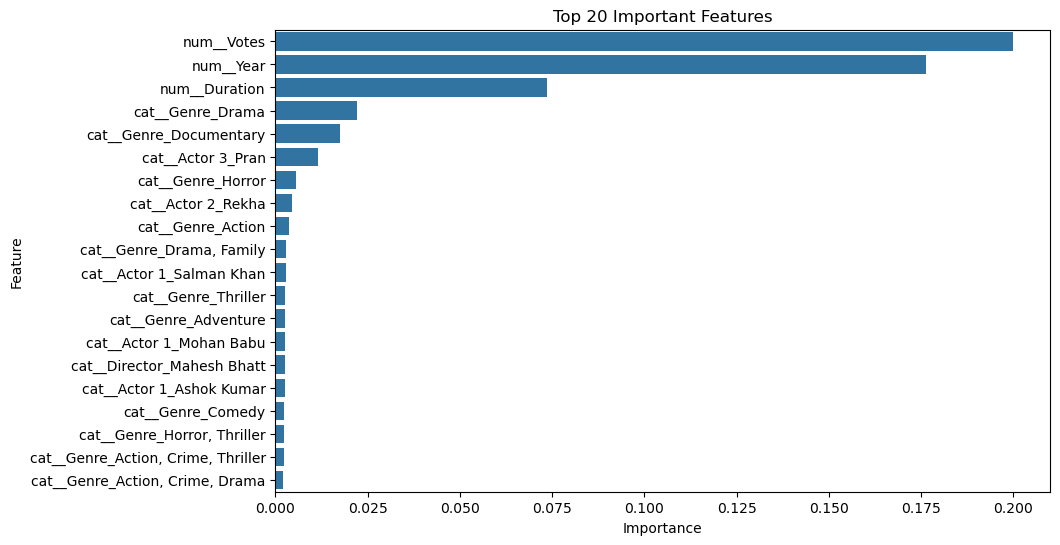

In [31]:
top_features = importance_df.head(20)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 20 Important Features")

plt.show()

In [32]:
sample_movie = pd.DataFrame({
    'Genre':['Drama'],
    'Director':['Sanjay Leela Bhansali'],
    'Actor 1':['Shah Rukh Khan'],
    'Actor 2':['Kajol'],
    'Actor 3':['Amrish Puri'],
    'Year':[2025],
    'Duration':[150],
    'Votes':[50000]
})

prediction = model.predict(sample_movie)

print("Predicted Rating:", round(prediction[0],2))

Predicted Rating: 6.69


In [33]:
import joblib

joblib.dump(
    model,
    "movie_rating_prediction.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!
